<a href="https://colab.research.google.com/github/pateld07/undergrad_ml_assignments/blob/main/02_assignment_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 2: $k$ Nearest Neighbor

### Do any four.

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?
Regression is when you predict a number, like the price of a house. Classification is when you predict a category, like yes or no. So regression gives a number, and classification gives a label.

2. What is a confusion table/matrix? What does it help us understand about a model's performance?
A confusion matrix is a chart that shows how many predictions were correct and incorrect. It shows true positives, true negatives, false positives, and false negatives. This helps us see what kinds of mistakes the model is making.

3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
Accuracy is the percentage of predictions that the model got correct out of all predictions. However, accuracy is not always enough to evaluate a classifier because if one class appears much more often than another, the model could predict the majority class every time and still have high accuracy, even though it is not actually performing well overall.

4. What does the root mean squared error quantify about a particular model?
Root mean squared error tells us how far off a regression model’s predictions are from the real answers. It measures the average size of the mistakes. A smaller Root mean squared means the model is better.

5. What are overfitting and underfitting?
Overfitting is when a model learns the training data too well and does badly on new data. Underfitting is when a model is too simple and does badly on both training and new data.

6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
Splitting data into training and testing sets helps us see how the model works on new data. Choosing the best k using the test set helps us pick a model that works well and does not just memorize.

7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.
In classification, we can predict just a label or give probabilities. A label is simple and easy to understand. Probabilities are better because they show how confident the model is, but they are a little more complicated.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).

The data is pretty balanced across the 5 mine types (they’re all around the same count), which is good because the model won’t just “guess the biggest class” all the time.

There are 338 total observations in the dataset. The features voltage, height, and soil are all scaled between 0 and 1. The average values are around 0.4 to 0.5, and the standard deviations show there is some variation in the data. Since k-NN uses distance to classify points, it is important that features are on similar scales. In this dataset, the features are already within the same range, which makes distance comparisons fair.

The scatterplots show how voltage, height, and soil relate to each other. Some mine types appear to form clusters, but there is also overlap between several classes. This means the model may confuse certain mine types because their measurements look similar.

2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)

I split the data 50/50 into training and test sets so that both sets are large enough since the dataset is not very big. I used stratify=y to make sure each mine type appears evenly in both sets. The training data is used to build the model, and the test data is used to evaluate its performance.

3. Build a $k$-NN classifier. Explain how you select $k$.

To select k, I trained models using different values of k from 1 to 30 and compared their accuracy on the test set. I chose the k value that gave the highest accuracy. If k is too small, the model can overfit and be too sensitive to noise. If k is too large, it can underfit and oversmooth the data. In this dataset, k = 1 gave the highest accuracy, so I selected that as the final model.

4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?

The overall accuracy of the model is about 46%, which means it correctly predicts the mine type less than half of the time. The confusion matrix shows that some mine types are predicted better than others, while some types are often confused with each other. This happens because the features overlap, so certain mines look similar based on voltage, height, and soil.

Even if a mine type has many correct predictions, it can still have many mistakes. This means we need to look at both the correct predictions and the errors in the confusion matrix to understand how well the model is really performing.

5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

The model only has about 46% accuracy, which means it makes many mistakes. Because this is about land mines, mistakes could be very dangerous. I would not use this model as the final decision. Instead, I would use it as a support tool to give an initial prediction. If the model predicts a mine type that is often confused with others, a human expert should double-check it. The model can help narrow down possibilities, but it should not replace careful inspection and safety procedures.

Used chatgpt 5 to help with 3rd and 4th question

In [ ]:
! git clone https://github.com/pateld07/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 27 (delta 5), reused 4 (delta 4), pack-reused 17 (from 1)
Receiving objects: 100% (27/27), 30.33 KiB | 1.21 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Download complete
Extracting data files...
Data extracted


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("./data/land_mines.csv", encoding="latin1")
df.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [ ]:
df["mine_type"].value_counts().sort_index()

,count
mine_type,
1,71
2,70
3,66
4,66
5,65


In [ ]:
df.describe()

,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


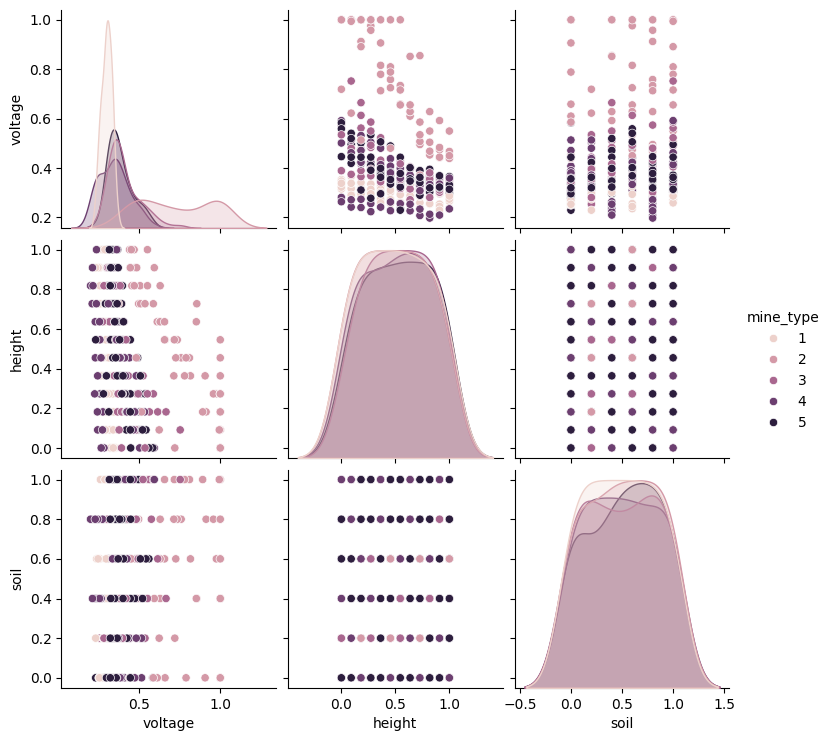

In [ ]:
sns.pairplot(df, hue="mine_type")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.5,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 169
Test set size: 169


In [ ]:
def minmax_with_train(train_df, test_df):
    train_min = train_df.min()
    train_max = train_df.max()
    train_scaled = (train_df - train_min) / (train_max - train_min)
    test_scaled  = (test_df  - train_min) / (train_max - train_min)
    return train_scaled, test_scaled

U_train, U_test = minmax_with_train(X_train, X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

ks = list(range(1, 31))
accs = []

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(U_train, y_train)
    pred = knn.predict(U_test)
    accs.append(accuracy_score(y_test, pred))

best_k = ks[np.argmax(accs)]
best_acc = max(accs)

print("Best k:", best_k)
print("Best accuracy:", best_acc)

Best k: 1
Best accuracy: 0.46153846153846156


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Train final model
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(U_train, y_train)

# Predict on test set
y_pred = final_model.predict(U_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[21  0  4  4  7]
 [ 0 32  0  3  0]
 [ 8  0  7 10  8]
 [ 7  5  4 11  6]
 [ 7  0  9  9  7]]
Accuracy: 0.46153846153846156

Classification Report:
              precision    recall  f1-score   support

           1       0.49      0.58      0.53        36
           2       0.86      0.91      0.89        35
           3       0.29      0.21      0.25        33
           4       0.30      0.33      0.31        33
           5       0.25      0.22      0.23        32

    accuracy                           0.46       169
   macro avg       0.44      0.45      0.44       169
weighted avg       0.45      0.46      0.45       169



**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.

The dataset contains price, year, and mileage for used cars. After selecting only these three variables, I checked for missing values. There were no missing values, so I did not need to remove or fill in any data.

2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?

As k increases, the predictions become smoother and less sensitive to individual data points. When k is small, such as 3, the predicted prices vary a lot and closely follow individual observations. This makes the model more flexible. As k becomes larger, the predictions begin clustering closer to the average price.

5. Determine the optimal $k$ for these data.

I determined the optimal k by comparing the mean squared error for each value of k. The smallest MSE occurred when k = 50, so I selected 50 as the optimal number of neighbors.

6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

When k is very small, like k = 3, the model tends to overfit. This means it fits the training data too closely and captures noise instead of the true pattern. In the scatterplots, predictions jump around more and try to match individual data points.

When k is very large, like k = 300, the model underfits. The predictions become overly smooth and cluster near the average price. This means the model is too simple and does not capture important variation in car prices.

The optimal value, k = 50, balances overfitting and underfitting.

In [ ]:
! git clone https://github.com/pateld07/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 27 (delta 5), reused 4 (delta 4), pack-reused 17 (from 1)
Receiving objects: 100% (27/27), 30.33 KiB | 1.60 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Download complete
Extracting data files...
Data extracted


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./data/USA_cars_datasets.csv", encoding="latin1")
df = df[["price", "year", "mileage"]]
df.head()


,price,year,mileage
0,6300,2008,274117
1,2899,2011,190552
2,5350,2018,39590
3,25000,2014,64146
4,27700,2018,6654


In [ ]:
df.shape

(2499, 3)

In [ ]:
df.isna().sum()

,0
price,0
year,0
mileage,0


In [ ]:
def minmax(x):
    return (x - x.min()) / (x.max() - x.min())

df["year"] = minmax(df["year"])
df["mileage"] = minmax(df["mileage"])

df.head()

,price,year,mileage
0,6300,0.744681,0.269287
1,2899,0.808511,0.187194
2,5350,0.957447,0.038892
3,25000,0.872340,0.063016
4,27700,0.957447,0.006537


In [ ]:
from sklearn.model_selection import train_test_split

X = df[["year", "mileage"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Training size: 1999
Test size: 500


k = 3 MSE = 148065935.51955554


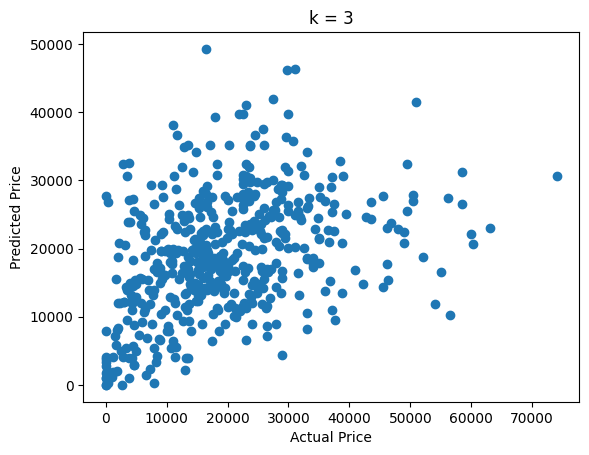

k = 10 MSE = 117399126.10604002


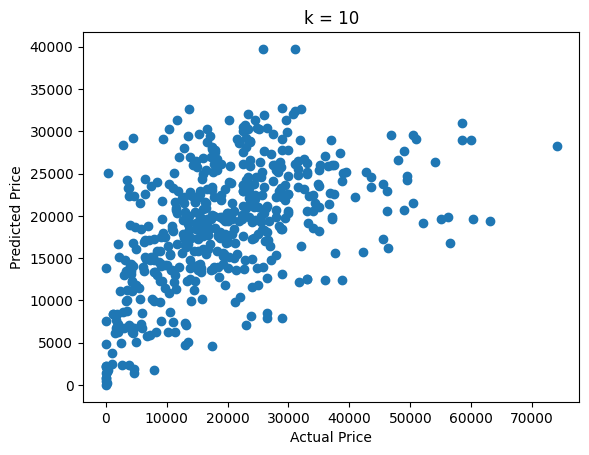

k = 25 MSE = 112576160.82390079


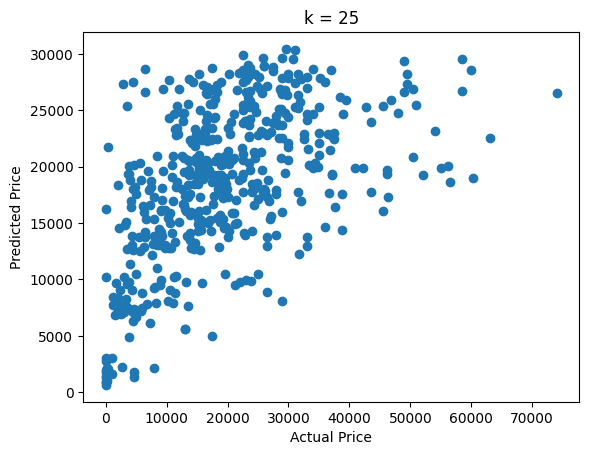

k = 50 MSE = 110202549.3014296


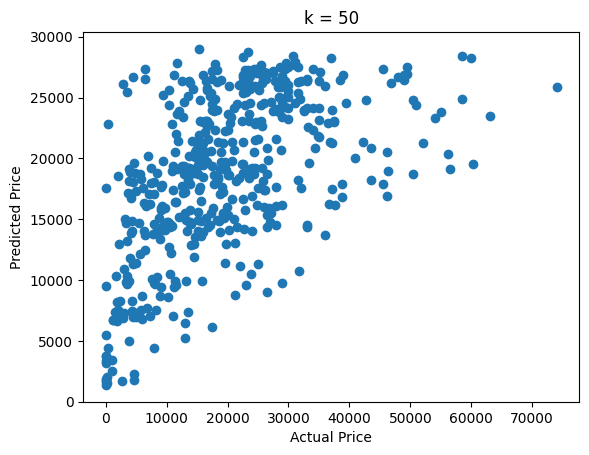

k = 100 MSE = 112253932.8184272


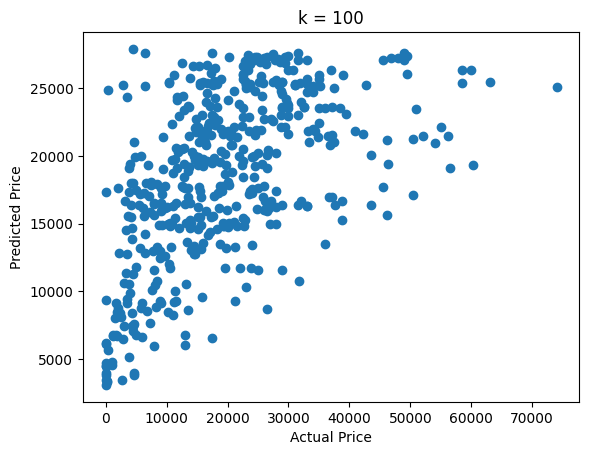

k = 300 MSE = 114496301.82933456


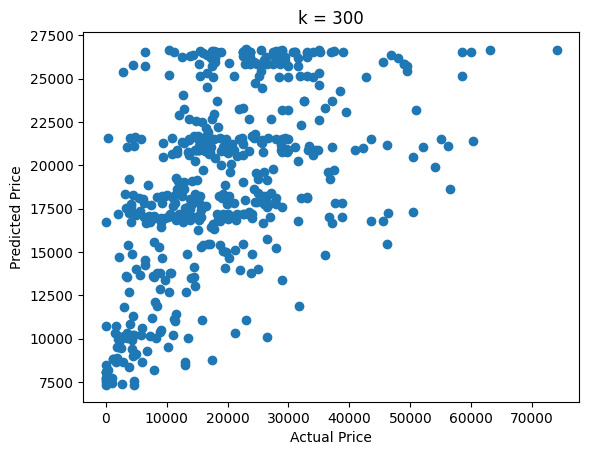

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

k_values = [3, 10, 25, 50, 100, 300]
mse_values = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mse_values.append(mse)

    print("k =", k, "MSE =", mse)

    # Scatterplot
    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(f"k = {k}")
    plt.show()

In [ ]:
best_k = k_values[np.argmin(mse_values)]
best_k

50

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on.

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)

I tested several values of k and calculated the mean squared error for each one. As k increased, the MSE decreased. The lowest MSE occurred when k = 100, so I selected 100 as the optimal number of neighbors for this model.
As k increased, the model’s predictions became more stable and the error decreased. Small values of k, like 3, had higher error because the model was too sensitive to individual data points. Larger values of k smoothed out the predictions and reduced the overall error.
When k is small, like k = 3, the model is more likely to overfit because it closely follows individual observations. This can make predictions more noisy.

As k increases, the model averages more neighbors, which reduces noise. However, if k becomes too large, the model may underfit by predicting values too close to the overall average.

In this dataset, k = 100 appears to balance this tradeoff well, since it gives the lowest MSE.

5. Predict the missing ratings.
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

The predicted missing ratings are more concentrated around the higher rating values compared to the training ratings. The predicted distribution looks smoother and more narrow. This happens because k-NN regression averages nearby values, which reduces extreme predictions. Overall, the imputed ratings follow the general pattern of the training ratings, but they are slightly more centered and less spread out.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("./data/airbnb_hw.csv", encoding="latin1")
df = df.loc[:, ["Review Scores Rating", "Price", "Beds"]]

df.head()

,Review Scores Rating,Price,Beds
0,NaN,145,1.0
1,NaN,37,1.0
2,NaN,28,1.0
3,NaN,199,3.0
4,96.0,549,3.0


In [ ]:
# Price is often stored like "$1,200" as text, so clean and convert it
df["Price"] = df["Price"].astype(str)
df["Price"] = df["Price"].str.replace("$", "", regex=False)
df["Price"] = df["Price"].str.replace(",", "", regex=False)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Convert Beds and Rating too
df["Beds"] = pd.to_numeric(df["Beds"], errors="coerce")
df["Review Scores Rating"] = pd.to_numeric(df["Review Scores Rating"], errors="coerce")

df.dtypes

,0
Review Scores Rating,float64
Price,int64
Beds,float64


In [ ]:
missing_df = df.loc[df["Review Scores Rating"].isnull(), :].copy()

df = df.dropna(axis=0, how="any")

print("Complete cases:", df.shape)
print("Missing ratings:", missing_df.shape)

Complete cases: (22111, 3)
Missing ratings: (0, 3)


In [ ]:
from sklearn.model_selection import train_test_split

X = df[["Price", "Beds"]]
y = df["Review Scores Rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((17688, 2), (4423, 2))

In [ ]:
def minmax_with_train(train_df, test_df):
    train_min = train_df.min()
    train_max = train_df.max()
    rng = train_max - train_min
    rng = rng.replace(0, 1)
    train_scaled = (train_df - train_min) / rng
    test_scaled  = (test_df  - train_min) / rng
    return train_scaled, test_scaled, train_min, train_max

U_train, U_test, train_min, train_max = minmax_with_train(X_train, X_test)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

k_values = [3, 10, 25, 50, 100]
mse_values = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(U_train, y_train)
    pred = model.predict(U_test)
    mse = mean_squared_error(y_test, pred)
    mse_values.append(mse)
    print("k =", k, "MSE =", mse)

best_k = k_values[np.argmin(mse_values)]
print("Best k:", best_k)

k = 3 MSE = 110.05968799457382
k = 10 MSE = 78.37146506895772
k = 25 MSE = 74.1723640967669
k = 50 MSE = 72.70983640063307
k = 100 MSE = 71.38675331223152
Best k: 100


In [ ]:
missing_pred_df = missing_df.dropna(subset=["Price", "Beds"]).copy()
missing_X = missing_pred_df[["Price", "Beds"]]
missing_scaled = (missing_X - train_min) / (train_max - train_min)
pred_missing = final_model.predict(missing_scaled)
missing_pred_df["Predicted Rating"] = pred_missing
missing_pred_df.head()

,Review Scores Rating,Price,Beds,Predicted Rating
0,NaN,145,1.0,93.66
1,NaN,37,1.0,88.22
2,NaN,28,1.0,86.74
3,NaN,199,3.0,88.85
13,NaN,68,1.0,91.05


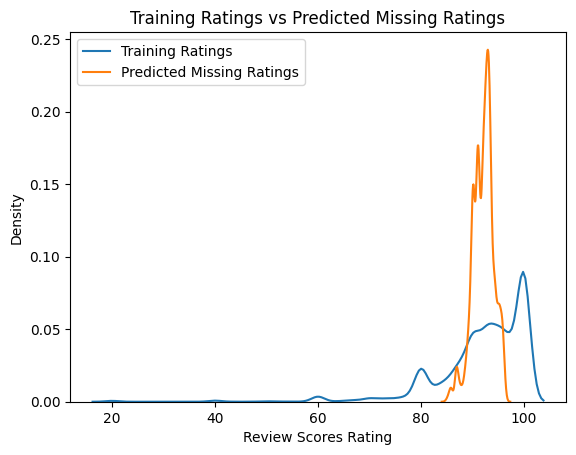

In [ ]:
plt.figure()
sns.kdeplot(y_train, label="Training Ratings")
sns.kdeplot(pred_missing, label="Predicted Missing Ratings")
plt.legend()
plt.title("Training Ratings vs Predicted Missing Ratings")
plt.show()

**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)